# Ablation Study: PhysioNet vs WSD4FEDSRM (Forearm)
## v6.1 — Сравнительный эксперимент

**Цель:** Определить вклад каждого датасета (PhysioNet, WSD4FEDSRM Forearm) в качество модели FatigueWristNet.

**Эксперименты:**
| # | Название | Данные | Sub-windowing | Ожидание |
|---|---------|--------|---------------|----------|
| 1 | `physionet_only` | PhysioNet (31 субъ., запястье) | Нет | Baseline, все has_physio=True |
| 2 | `wsd4fedsrm_forearm` | WSD4FEDSRM Forearm (34 субъ.) | Да (×3) | has_physio=False, мало окон |
| 3 | `combined_wrist` | PhysioNet + WSD Forearm (65 субъ.) | Да (WSD only) | Если лучше #1 → Forearm полезен |

**Модель:** FatigueWristNet (IMU + Physio dual-branch), единый CONFIG для всех экспериментов.

**Метрики:** val_F1, test_F1, ROC-AUC, PR-AUC, best_epoch, LOSO F1 (median ± IQR)

In [1]:
# ── 1. Imports ──
import os, sys, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve,
    auc, roc_curve,
)
from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample
from imblearn.over_sampling import SMOTE

sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

SEED = 4544655

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed: {SEED}")

# ── Project root ──
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(f"Marker '{marker}' not found from {os.getcwd()}")

PROJECT_ROOT = find_project_root('config.yaml')
RESULTS_DIR = (PROJECT_ROOT / 'results_v7_ablation').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")

PyTorch: 2.10.0+cu130, CUDA: True
Device: cuda
Seed: 4544655
Project root: D:\Github\afc_lab
Results dir:  D:\Github\afc_lab\results_v7_ablation


## 2. CONFIG + Experiment definitions

Единый CONFIG для всех 3 экспериментов — честное сравнение.

In [2]:
CONFIG = {
    # --- Training ---
    'batch_size': 64,
    'epochs': 50,
    'lr': 1e-4,
    'weight_decay': 1e-2,
    'patience': 10,
    'min_delta': 2e-4,

    # --- Architecture: IMU Encoder ---
    'imu_channels': 6,
    'encoder_channels': 16,
    'encoder_dropout': 0.375,
    'kernel_sizes': [7, 5, 3],

    # --- Architecture: Physio Encoder ---
    'physio_channels': 4,
    'physio_encoder_channels': 8,

    # --- Architecture: Classifier ---
    'classifier_dropout': 0.55,

    # --- Focal Loss ---
    'focal_gamma': 2.0,

    # --- Evaluation ---
    'min_precision_for_recall': 0.3,
}

print("CONFIG (unified for all experiments):")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

# ── Experiment definitions ──
EXPERIMENTS = {
    'physionet_only': {
        'data_file': 'physionet_only.npz',
        'expected_domains': {'physionet'},
        'use_sub_windowing': False,
        'description': 'PhysioNet only (Empatica E4, wrist)',
    },
    'wsd4fedsrm_forearm': {
        'data_file': 'wsd4fedsrm_only.npz',
        'expected_domains': {'wsd4fedsrm'},
        'use_sub_windowing': True,
        'description': 'WSD4FEDSRM Forearm only',
    },
    'combined_wrist': {
        'data_file': 'wrist_combined.npz',
        'expected_domains': {'physionet', 'wsd4fedsrm'},
        'use_sub_windowing': True,  # for WSD portion only
        'description': 'PhysioNet + WSD4FEDSRM Forearm',
    },
}

print(f"\n{len(EXPERIMENTS)} experiments defined:")
for name, exp in EXPERIMENTS.items():
    print(f"  {name}: {exp['description']} ({exp['data_file']})")

CONFIG (unified for all experiments):
  batch_size: 64
  epochs: 50
  lr: 0.0001
  weight_decay: 0.01
  patience: 10
  min_delta: 0.0002
  imu_channels: 6
  encoder_channels: 16
  encoder_dropout: 0.375
  kernel_sizes: [7, 5, 3]
  physio_channels: 4
  physio_encoder_channels: 8
  classifier_dropout: 0.55
  focal_gamma: 2.0
  min_precision_for_recall: 0.3

3 experiments defined:
  physionet_only: PhysioNet only (Empatica E4, wrist) (physionet_only.npz)
  wsd4fedsrm_forearm: WSD4FEDSRM Forearm only (wsd4fedsrm_only.npz)
  combined_wrist: PhysioNet + WSD4FEDSRM Forearm (wrist_combined.npz)


## 3. Utilities (augmentation, SMOTE, model, training)

Всё то же, что в v6.0 — без изменений в архитектуре.
Код вынесен в единую ячейку для переиспользования в `run_experiment()`.

In [3]:
# ══════════════════════════════════════════════════════════════════
# Subject-level split
# ══════════════════════════════════════════════════════════════════

def create_subject_split(subjects, domains, y, test_size=0.2, val_size=0.2, seed=SEED):
    subj_df = pd.DataFrame({'sid': subjects, 'domain': domains}).drop_duplicates('sid')
    sids = subj_df['sid'].to_numpy(dtype=object)
    doms = subj_df['domain'].to_numpy(dtype=object)

    strat = doms if len(np.unique(doms)) > 1 else None
    sid_tv, sid_test = train_test_split(
        sids, test_size=test_size, random_state=seed, stratify=strat)

    val_rel = val_size / (1.0 - test_size)
    sid_to_domain = dict(zip(sids, doms))
    tv_doms = np.array([sid_to_domain[s] for s in sid_tv])
    strat_v = tv_doms if len(np.unique(tv_doms)) > 1 else None
    sid_train, sid_val = train_test_split(
        sid_tv, test_size=val_rel, random_state=seed, stratify=strat_v)

    tr_idx = np.where(np.isin(subjects, sid_train))[0]
    va_idx = np.where(np.isin(subjects, sid_val))[0]
    te_idx = np.where(np.isin(subjects, sid_test))[0]

    for name, idx in [('Train', tr_idx), ('Val', va_idx), ('Test', te_idx)]:
        if len(np.unique(y[idx])) < 2:
            raise ValueError(f"{name} split has only one class")

    return tr_idx, va_idx, te_idx


# ══════════════════════════════════════════════════════════════════
# Augmentation
# ══════════════════════════════════════════════════════════════════

def add_gaussian_noise(x, sigma=0.05):
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)

def time_warp(x, sigma=0.2, knots=4):
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([CubicSpline(t_orig, x[:, c])(t_warped)
                     for c in range(C)], axis=-1).astype(x.dtype)

def channel_dropout(x, p=0.2):
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x

def magnitude_scale(x, lo=0.7, hi=1.3):
    return x * np.random.uniform(lo, hi, (1, x.shape[1])).astype(x.dtype)

def window_slice(x, crop_lo=0.6, crop_hi=0.9):
    T, C = x.shape
    crop = np.random.uniform(crop_lo, crop_hi)
    L = max(int(T * crop), 10)
    s = np.random.randint(0, T - L + 1)
    return sp_resample(x[s:s + L], T, axis=0).astype(x.dtype)

def time_reverse(x):
    return x[::-1].copy()

def imu_rotate(x, max_deg=20.0):
    def _rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K
    x = x.copy()
    x[:, :3] = x[:, :3] @ _rot().T
    if x.shape[1] >= 6:
        x[:, 3:6] = x[:, 3:6] @ _rot().T
    return x.astype(np.float32)

def permutation_segments(x, n_segments=4):
    T, C = x.shape
    seg_len = T // n_segments
    if seg_len < 2:
        return x
    segments = [x[i * seg_len:(i + 1) * seg_len] for i in range(n_segments)]
    remainder = x[n_segments * seg_len:]
    np.random.shuffle(segments)
    result = np.concatenate(segments + ([remainder] if len(remainder) else []), axis=0)
    return result.astype(x.dtype)

def frequency_mask(x, max_mask_ratio=0.15):
    T, C = x.shape
    x_out = x.copy()
    for c in range(C):
        freq = np.fft.rfft(x[:, c])
        n_freq = len(freq)
        mask_len = max(1, int(n_freq * max_mask_ratio))
        start = np.random.randint(0, max(1, n_freq - mask_len))
        freq[start:start + mask_len] = 0
        x_out[:, c] = np.fft.irfft(freq, n=T)
    return x_out.astype(x.dtype)

def compute_sample_difficulty(x_imu):
    per_channel_std = np.std(x_imu, axis=0)
    return float(np.mean(per_channel_std))

IMU_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.03, 0.10))),
    ('time_warp', lambda x: time_warp(x, sigma=np.random.uniform(0.15, 0.35), knots=4)),
    ('scale',     lambda x: magnitude_scale(x, 0.7, 1.3)),
    ('crop',      lambda x: window_slice(x, 0.6, 0.9)),
    ('reverse',   lambda x: time_reverse(x)),
    ('rotate',    lambda x: imu_rotate(x, max_deg=20.0)),
    ('permute',   lambda x: permutation_segments(x, n_segments=np.random.randint(3, 6))),
    ('freq_mask', lambda x: frequency_mask(x, max_mask_ratio=0.15)),
]

PHYSIO_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.02, 0.06))),
    ('scale',     lambda x: magnitude_scale(x, 0.85, 1.15)),
    ('time_warp', lambda x: time_warp(x, sigma=0.1, knots=3)),
]

def augment_sample(x_imu, x_physio):
    difficulty = compute_sample_difficulty(x_imu)
    border_score = 1.0 - abs(difficulty - 0.8) / max(difficulty + 0.3, 1e-6)
    border_score = np.clip(border_score, 0, 1)
    n_imu_aug = 3 + int(2 * border_score)
    n_physio_aug = 1 + int(border_score >= 0.5)

    imu_choices = np.random.choice(len(IMU_TRANSFORMS), size=min(n_imu_aug, len(IMU_TRANSFORMS)), replace=False)
    for idx in imu_choices:
        _, fn = IMU_TRANSFORMS[idx]
        x_imu = fn(x_imu)
    x_imu = channel_dropout(x_imu, 0.2)

    physio_choices = np.random.choice(len(PHYSIO_TRANSFORMS), size=min(n_physio_aug, len(PHYSIO_TRANSFORMS)), replace=False)
    for idx in physio_choices:
        _, fn = PHYSIO_TRANSFORMS[idx]
        x_physio = fn(x_physio)

    return x_imu, x_physio


# ══════════════════════════════════════════════════════════════════
# SMOTE (dual-branch)
# ══════════════════════════════════════════════════════════════════

def apply_smote_dual_branch(X_imu, X_physio, y, has_physio_arr, k_neighbors=5, random_state=SEED):
    N, T, C_imu = X_imu.shape
    C_physio = X_physio.shape[2]
    flat_imu = X_imu.reshape(N, -1)
    flat_physio = X_physio.reshape(N, -1)
    X_flat = np.hstack([flat_imu, flat_physio])

    class_counts = np.bincount(y.astype(int))
    min_class_count = class_counts.min()
    k = min(k_neighbors, min_class_count - 1)
    if k < 1:
        print("   ⚠️ SMOTE: insufficient samples, skipping")
        return X_imu, X_physio, y, has_physio_arr

    smote = SMOTE(k_neighbors=k, random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_flat, y.astype(int))

    N_new = len(y_resampled)
    imu_flat = X_resampled[:, :T * C_imu]
    physio_flat = X_resampled[:, T * C_imu:]
    X_imu_new = imu_flat.reshape(N_new, T, C_imu).astype(np.float32)
    X_physio_new = physio_flat.reshape(N_new, T, C_physio).astype(np.float32)

    hp_new = np.zeros(N_new, dtype=bool)
    hp_new[:N] = has_physio_arr
    for cls in [0, 1]:
        cls_mask_orig = y.astype(int) == cls
        if cls_mask_orig.any():
            physio_ratio = has_physio_arr[cls_mask_orig].mean()
            cls_mask_new = (y_resampled == cls) & (np.arange(N_new) >= N)
            hp_new[cls_mask_new] = physio_ratio > 0.5

    n_synth = N_new - N
    print(f"   SMOTE: {N} → {N_new} (+{n_synth} synthetic, k={k})")
    return X_imu_new, X_physio_new, y_resampled.astype(np.int64), hp_new


# ══════════════════════════════════════════════════════════════════
# FatigueDataset
# ══════════════════════════════════════════════════════════════════

class FatigueDataset(Dataset):
    def __init__(self, X_imu, X_physio, y, has_physio, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        xi, xp = self.X_imu[idx].copy(), self.X_physio[idx].copy()
        if self.augment:
            xi, xp = augment_sample(xi, xp)
        return (torch.FloatTensor(xi),
                torch.FloatTensor(xp),
                torch.tensor(self.has_physio[idx], dtype=torch.float32),
                torch.tensor(self.y[idx], dtype=torch.float32))


# ══════════════════════════════════════════════════════════════════
# FatigueWristNet
# ══════════════════════════════════════════════════════════════════

class TemporalAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 4, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(channels // 4, 1, kernel_size=1),
        )
    def forward(self, x):
        w = torch.softmax(self.score(x), dim=-1)
        return (x * w).sum(dim=-1)

class IMUEncoderWithAttention(nn.Module):
    def __init__(self, in_channels, out_channels, dropout, kernel_sizes):
        super().__init__()
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, k1, padding=k1 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k2, padding=k2 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k3, padding=k3 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
        )
        self.attention = TemporalAttention(out_channels)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv3(self.conv2(self.conv1(x)))
        return self.attention(x)

class PhysioEncoder(nn.Module):
    def __init__(self, in_channels, out_channels, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True), nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        return self.net(x.transpose(1, 2)).squeeze(-1)

class FatigueWristNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        enc_ch = cfg['encoder_channels']
        physio_enc_ch = cfg['physio_encoder_channels']
        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=cfg['imu_channels'], out_channels=enc_ch,
            dropout=cfg['encoder_dropout'], kernel_sizes=cfg['kernel_sizes'],
        )
        self.physio_encoder = PhysioEncoder(
            in_channels=cfg['physio_channels'], out_channels=physio_enc_ch,
            dropout=cfg['encoder_dropout'],
        )
        feat_dim = enc_ch + physio_enc_ch
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, feat_dim // 2),
            nn.ReLU(True),
            nn.Dropout(cfg['classifier_dropout']),
            nn.Linear(feat_dim // 2, 1),
        )
    def forward(self, x_imu, x_physio, has_physio=None):
        imu_feat = self.imu_encoder(x_imu)
        physio_feat = self.physio_encoder(x_physio)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.unsqueeze(-1)
        combined = torch.cat([imu_feat, physio_feat], dim=1)
        return self.classifier(combined).squeeze(-1)
    def predict_proba(self, x_imu, x_physio, has_physio=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio))


# ══════════════════════════════════════════════════════════════════
# Loss, Metrics, EarlyStopping, Train/Val
# ══════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()

def compute_class_domain_weights(y, domains):
    weights = np.zeros(len(y), dtype=np.float64)
    unique_doms = np.unique(domains)
    for dom in unique_doms:
        for cls in [0, 1]:
            mask = (domains == dom) & (y == cls)
            n = mask.sum()
            if n > 0:
                weights[mask] = len(y) / (2 * len(unique_doms) * n)
    return weights

def compute_pos_weight(y):
    n_pos = y.sum()
    return (len(y) - n_pos) / max(n_pos, 1)

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }
    if np.unique(y_true).size >= 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        pr, rc, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(rc, pr)
    else:
        metrics['roc_auc'] = metrics['pr_auc'] = np.nan
    return metrics, y_pred

def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, ema_alpha=0.3):
        self.patience = patience
        self.min_delta = min_delta
        self.alpha = ema_alpha
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None
        self._ema = None

    def smooth(self, score):
        if self._ema is None:
            self._ema = score
        else:
            self._ema = self.alpha * score + (1 - self.alpha) * self._ema
        return self._ema

    def __call__(self, score, model):
        ema_score = self.smooth(score)
        if ema_score > self.best_score + self.min_delta:
            self.best_score = ema_score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    @property
    def ema(self):
        return self._ema if self._ema is not None else 0.0

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_imu, x_physio, hp, y in loader:
        x_imu, x_physio, hp, y = x_imu.to(device), x_physio.to(device), hp.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_imu, x_physio, hp), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)

def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for x_imu, x_physio, hp, y in loader:
            x_imu, x_physio, hp, y = x_imu.to(device), x_physio.to(device), hp.to(device), y.to(device)
            logits = model(x_imu, x_physio, hp)
            total_loss += criterion(logits, y).item() * len(y)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    probs = np.array(all_probs, dtype=np.float32)
    labels = np.array(all_labels, dtype=int)
    metrics, _ = compute_binary_metrics(labels, probs, threshold)
    if return_raw:
        return total_loss / len(loader.dataset), metrics, labels, probs
    return total_loss / len(loader.dataset), metrics

print("✅ All utilities defined (augmentation, SMOTE, model, training)")

✅ All utilities defined (augmentation, SMOTE, model, training)


## 4. `run_experiment()` — полный pipeline в одной функции

Загрузка NPZ → фильтрация → sub-windowing → split → SMOTE → train → eval → LOSO.
Возвращает dict с метриками и историей обучения.

In [4]:
def run_experiment(data_file, experiment_name, config, expected_domains,
                   use_sub_windowing=False, loso_folds=10, loso_epochs=15):
    """
    Full pipeline: load → filter → sub-window → split → SMOTE → train → eval → LOSO.

    Returns dict with all metrics, history, and LOSO results.
    """
    set_seed(SEED)
    data_path = PROJECT_ROOT / 'data' / 'processed' / data_file

    print("=" * 70)
    print(f"  EXPERIMENT: {experiment_name}")
    print(f"  Data: {data_file} | Domains: {expected_domains}")
    print(f"  Sub-windowing: {use_sub_windowing}")
    print("=" * 70)

    # ── 1. Load & filter ──
    data = np.load(data_path, allow_pickle=True)
    X_imu_raw = data['X_imu'].astype(np.float32)
    X_physio_raw = data['X_physio'].astype(np.float32)
    y_raw = data['y'].astype(np.int64)
    subjects_raw = data['pids']
    domains_raw = data['domains']
    has_physio_raw = data['has_physio'].astype(bool)

    keep = np.isin(domains_raw, list(expected_domains))
    X_imu_filt = X_imu_raw[keep]
    X_physio_filt = X_physio_raw[keep]
    y_filt = y_raw[keep]
    subjects_filt = subjects_raw[keep]
    domains_filt = domains_raw[keep]
    has_physio_filt = has_physio_raw[keep]

    print(f"\n  Filtered: {keep.sum()} windows, {len(np.unique(subjects_filt))} subjects")
    print(f"  Domains: {dict(zip(*np.unique(domains_filt, return_counts=True)))}")
    print(f"  has_physio: {has_physio_filt.sum()}/{len(has_physio_filt)}")
    print(f"  Balance: {y_filt.mean():.1%} fatigue")

    # ── 2. WSD sub-windowing (if enabled, only for wsd4fedsrm) ──
    if use_sub_windowing and 'wsd4fedsrm' in expected_domains:
        WSD_SUB_CROP = 0.6
        WSD_SUB_STRIDE = 0.2
        TARGET_LEN = 100

        wsd_mask = domains_filt == 'wsd4fedsrm'
        other_mask = ~wsd_mask

        wsd_imu = X_imu_filt[wsd_mask]
        wsd_physio = X_physio_filt[wsd_mask]
        wsd_y = y_filt[wsd_mask]
        wsd_subj = subjects_filt[wsd_mask]
        wsd_hp = has_physio_filt[wsd_mask]

        new_imu, new_physio, new_y, new_subj, new_hp = [], [], [], [], []
        T = wsd_imu.shape[1]
        crop_len = int(T * WSD_SUB_CROP)
        stride_pts = int(T * WSD_SUB_STRIDE)

        for i in range(len(wsd_imu)):
            new_imu.append(wsd_imu[i])
            new_physio.append(wsd_physio[i])
            new_y.append(wsd_y[i])
            new_subj.append(wsd_subj[i])
            new_hp.append(wsd_hp[i])
            for start in range(0, T - crop_len + 1, stride_pts):
                if start == 0 and crop_len == T:
                    continue
                seg_imu = wsd_imu[i, start:start + crop_len, :]
                seg_physio = wsd_physio[i, start:start + crop_len, :]
                resampled_imu = sp_resample(seg_imu, TARGET_LEN, axis=0).astype(np.float32)
                resampled_physio = sp_resample(seg_physio, TARGET_LEN, axis=0).astype(np.float32)
                new_imu.append(resampled_imu)
                new_physio.append(resampled_physio)
                new_y.append(wsd_y[i])
                new_subj.append(wsd_subj[i])
                new_hp.append(wsd_hp[i])

        wsd_imu_exp = np.stack(new_imu)
        wsd_physio_exp = np.stack(new_physio)
        wsd_y_exp = np.array(new_y, dtype=np.int64)
        wsd_subj_exp = np.array(new_subj)
        wsd_hp_exp = np.array(new_hp)

        X_imu_all = np.concatenate([X_imu_filt[other_mask], wsd_imu_exp], axis=0)
        X_physio_all = np.concatenate([X_physio_filt[other_mask], wsd_physio_exp], axis=0)
        y_all = np.concatenate([y_filt[other_mask], wsd_y_exp])
        subjects = np.concatenate([subjects_filt[other_mask], wsd_subj_exp])
        domains = np.concatenate([domains_filt[other_mask], np.full(len(wsd_y_exp), 'wsd4fedsrm')])
        has_physio_arr = np.concatenate([has_physio_filt[other_mask], wsd_hp_exp])

        print(f"  Sub-windowing: WSD {wsd_mask.sum()} → {len(wsd_y_exp)} (×{len(wsd_y_exp)/max(wsd_mask.sum(),1):.1f})")
    else:
        X_imu_all = X_imu_filt
        X_physio_all = X_physio_filt
        y_all = y_filt
        subjects = subjects_filt
        domains = domains_filt
        has_physio_arr = has_physio_filt

    print(f"  Final: {len(y_all)} windows, {len(np.unique(subjects))} subjects")

    # ── 3. Subject-level split ──
    train_idx, val_idx, test_idx = create_subject_split(subjects, domains, y_all)
    for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
        dom_counts = dict(zip(*np.unique(domains[idx], return_counts=True)))
        cls = np.bincount(y_all[idx].astype(int), minlength=2)
        print(f"  {name:5s}: {len(idx):>6} wins, {len(np.unique(subjects[idx]))} subj | "
              f"doms={dom_counts} | 0→{cls[0]}, 1→{cls[1]} ({y_all[idx].mean():.1%})")

    # ── 4. SMOTE ──
    X_imu_train_raw = X_imu_all[train_idx]
    X_physio_train_raw = X_physio_all[train_idx]
    y_train_raw = y_all[train_idx]
    hp_train_raw = has_physio_arr[train_idx]
    domains_train_raw = domains[train_idx]

    X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm = apply_smote_dual_branch(
        X_imu_train_raw, X_physio_train_raw, y_train_raw, hp_train_raw,
        k_neighbors=5, random_state=SEED)

    # Domains for SMOTE samples
    domains_train_sm = np.empty(len(y_train_sm), dtype=domains_train_raw.dtype)
    domains_train_sm[:len(domains_train_raw)] = domains_train_raw
    minority_cls = 0 if (y_train_raw == 0).sum() < (y_train_raw == 1).sum() else 1
    minority_doms = domains_train_raw[y_train_raw == minority_cls]
    if len(minority_doms) > 0:
        n_synth = len(y_train_sm) - len(y_train_raw)
        synth_doms = np.random.choice(minority_doms, size=n_synth, replace=True)
        domains_train_sm[len(domains_train_raw):] = synth_doms

    # ── 5. DataLoaders ──
    train_ds = FatigueDataset(X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm, augment=True)
    val_ds = FatigueDataset(X_imu_all[val_idx], X_physio_all[val_idx], y_all[val_idx], has_physio_arr[val_idx])
    test_ds = FatigueDataset(X_imu_all[test_idx], X_physio_all[test_idx], y_all[test_idx], has_physio_arr[test_idx])

    sample_weights = compute_class_domain_weights(y_train_sm, domains_train_sm)
    train_sampler = WeightedRandomSampler(
        torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=config['batch_size'], sampler=train_sampler, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=config['batch_size'], shuffle=False, num_workers=0)

    # ── 6. Model + Optimizer ──
    model = FatigueWristNet(config).to(DEVICE)
    pw = compute_pos_weight(y_train_sm)
    criterion = FocalLoss(gamma=config['focal_gamma'], pos_weight=torch.tensor([pw]).to(DEVICE))
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'], eta_min=1e-6)
    early_stopping = EarlyStopping(patience=config['patience'], min_delta=config['min_delta'])

    print(f"\n  Model: {sum(p.numel() for p in model.parameters()):,} params")
    print(f"  Train: {len(train_ds)} (SMOTE), Val: {len(val_ds)}, Test: {len(test_ds)}")

    # ── 7. Training loop ──
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auc': [],
               'val_pr_auc': [], 'val_bal_acc': [], 'val_f1_ema': [], 'lr': []}
    best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5

    for epoch in range(config['epochs']):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, vm, val_labels, val_probs = validate(
            model, val_loader, criterion, DEVICE, return_raw=True)
        scheduler.step()
        lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(vm['f1_macro'])
        history['val_auc'].append(vm['roc_auc'])
        history['val_pr_auc'].append(vm['pr_auc'])
        history['val_bal_acc'].append(vm['balanced_acc'])
        history['lr'].append(lr)

        stop = early_stopping(vm['f1_macro'], model)
        history['val_f1_ema'].append(early_stopping.ema)

        if vm['f1_macro'] > best_val_f1 + config['min_delta']:
            best_val_f1, best_epoch = vm['f1_macro'], epoch + 1
            best_threshold, _ = find_best_threshold(val_labels, val_probs)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Ep {epoch+1:3d}/{config['epochs']} | "
                  f"TrL: {train_loss:.4f} | VaL: {val_loss:.4f} | "
                  f"F1: {vm['f1_macro']:.4f} (ema={early_stopping.ema:.4f}) | "
                  f"AUC: {vm['roc_auc']:.4f}")

        if stop:
            print(f"  Early stop at epoch {epoch + 1}")
            break

    if early_stopping.best_model is not None:
        model.load_state_dict(early_stopping.best_model)

    print(f"  ✅ Best ep={best_epoch}, val_F1={best_val_f1:.4f}, threshold={best_threshold:.3f}")

    # ── 8. Test evaluation ──
    test_loss, test_metrics, test_labels, test_probs = validate(
        model, test_loader, criterion, DEVICE, threshold=best_threshold, return_raw=True)
    _, test_preds = compute_binary_metrics(test_labels, test_probs, best_threshold)

    print(f"\n  TEST: F1={test_metrics['f1_macro']:.4f}, "
          f"AUC={test_metrics['roc_auc']:.4f}, PR-AUC={test_metrics['pr_auc']:.4f}")

    # ── 9. LOSO ──
    print(f"\n  Running LOSO ({loso_folds} folds)...")
    loso_df = _loso_evaluation(
        X_imu_all, X_physio_all, y_all, subjects, domains, has_physio_arr,
        config, n_folds=loso_folds, epochs=loso_epochs)

    loso_f1_median = loso_df['f1_macro'].median()
    loso_f1_iqr = loso_df['f1_macro'].quantile(0.75) - loso_df['f1_macro'].quantile(0.25)
    print(f"  LOSO: F1 median={loso_f1_median:.4f}, IQR={loso_f1_iqr:.4f}")

    # Per-domain LOSO
    for dom in loso_df['domain'].unique():
        d = loso_df[loso_df['domain'] == dom]
        print(f"    {dom}: F1 median={d['f1_macro'].median():.4f} "
              f"(IQR={d['f1_macro'].quantile(0.75) - d['f1_macro'].quantile(0.25):.4f}), n={len(d)}")

    return {
        'name': experiment_name,
        'best_epoch': best_epoch,
        'best_threshold': best_threshold,
        'val_f1': best_val_f1,
        'test_f1': test_metrics['f1_macro'],
        'test_roc_auc': test_metrics['roc_auc'],
        'test_pr_auc': test_metrics['pr_auc'],
        'test_bal_acc': test_metrics['balanced_acc'],
        'train_val_gap': history['train_loss'][-1] - history['val_loss'][-1],
        'loso_f1_median': loso_f1_median,
        'loso_f1_iqr': loso_f1_iqr,
        'history': history,
        'loso_df': loso_df,
        'test_labels': test_labels,
        'test_probs': test_probs,
        'test_preds': test_preds,
        'n_windows': len(y_all),
        'n_subjects': len(np.unique(subjects)),
    }


def _loso_evaluation(X_imu, X_physio, y, subjects, domains, has_physio_arr,
                     config, n_folds=10, epochs=15, min_windows=20, patience=5):
    """LOSO with dual-branch model, Focal Loss, fold limit."""
    unique_subj = np.unique(subjects)
    folds = [{'train_idx': np.where(subjects != s)[0],
              'test_idx': np.where(subjects == s)[0], 'subject': s}
             for s in unique_subj]
    folds = [f for f in folds
             if len(f['test_idx']) >= min_windows
             and len(np.unique(y[f['test_idx']])) >= 2]

    if len(folds) > n_folds:
        np.random.seed(SEED)
        folds = [folds[i] for i in np.random.choice(len(folds), n_folds, replace=False)]

    results = []
    for fold in tqdm(folds, desc=f'LOSO', leave=False):
        tr, te = fold['train_idx'], fold['test_idx']
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
            sub_tr, sub_val = next(sss.split(tr, y[tr]))
            vi, ti = tr[sub_val], tr[sub_tr]
        except ValueError:
            ti, vi = tr, te

        tr_ds = FatigueDataset(X_imu[ti], X_physio[ti], y[ti], has_physio_arr[ti], augment=True)
        va_ds = FatigueDataset(X_imu[vi], X_physio[vi], y[vi], has_physio_arr[vi])
        te_ds = FatigueDataset(X_imu[te], X_physio[te], y[te], has_physio_arr[te])

        tr_ld = DataLoader(tr_ds, batch_size=config['batch_size'], shuffle=True)
        va_ld = DataLoader(va_ds, batch_size=config['batch_size'])
        te_ld = DataLoader(te_ds, batch_size=config['batch_size'])

        m = FatigueWristNet(config).to(DEVICE)
        pw = compute_pos_weight(y[ti])
        crit = FocalLoss(gamma=config['focal_gamma'], pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=3e-4)

        best_f1, best_st, no_imp = -np.inf, None, 0
        for ep in range(epochs):
            train_epoch(m, tr_ld, opt, crit, DEVICE)
            _, vm = validate(m, va_ld, crit, DEVICE)
            if vm['f1_macro'] > best_f1 + 1e-4:
                best_f1 = vm['f1_macro']
                best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

        if best_st:
            m.load_state_dict(best_st)
        _, tm = validate(m, te_ld, crit, DEVICE)

        results.append({
            'subject': fold['subject'],
            'domain': domains[te][0],
            'f1_macro': tm['f1_macro'],
            'roc_auc': tm['roc_auc'],
            'n_samples': len(te),
        })

    return pd.DataFrame(results)


print("✅ run_experiment() defined")

✅ run_experiment() defined


## 5. Запуск экспериментов

Три эксперимента с единым CONFIG. Результаты сохраняются в `all_results`.

In [5]:
# ── Run all experiments ──
all_results = {}

for exp_name, exp_cfg in EXPERIMENTS.items():
    result = run_experiment(
        data_file=exp_cfg['data_file'],
        experiment_name=exp_name,
        config=CONFIG,
        expected_domains=exp_cfg['expected_domains'],
        use_sub_windowing=exp_cfg['use_sub_windowing'],
        loso_folds=10,
        loso_epochs=15,
    )
    all_results[exp_name] = result
    print(f"\n{'─' * 70}\n")

print("✅ All experiments complete!")

  EXPERIMENT: physionet_only
  Data: physionet_only.npz | Domains: {'physionet'}
  Sub-windowing: False

  Filtered: 23034 windows, 31 subjects
  Domains: {np.str_('physionet'): np.int64(23034)}
  has_physio: 23034/23034
  Balance: 43.2% fatigue
  Final: 23034 windows, 31 subjects
  Train:  13523 wins, 18 subj | doms={np.str_('physionet'): np.int64(13523)} | 0→7604, 1→5919 (43.8%)
  Val  :   4191 wins, 6 subj | doms={np.str_('physionet'): np.int64(4191)} | 0→2480, 1→1711 (40.8%)
  Test :   5320 wins, 7 subj | doms={np.str_('physionet'): np.int64(5320)} | 0→2993, 1→2327 (43.7%)
   SMOTE: 13523 → 15208 (+1685 synthetic, k=5)

  Model: 3,698 params
  Train: 15208 (SMOTE), Val: 4191, Test: 5320
  Ep   1/50 | TrL: 0.1854 | VaL: 0.1593 | F1: 0.6597 (ema=0.6597) | AUC: 0.7036
  Ep  10/50 | TrL: 0.1238 | VaL: 0.1209 | F1: 0.7861 (ema=0.7855) | AUC: 0.8666
  Ep  20/50 | TrL: 0.1186 | VaL: 0.1203 | F1: 0.7872 (ema=0.7911) | AUC: 0.8618
  Early stop at epoch 29
  ✅ Best ep=8, val_F1=0.7993, thres

  LOSO: F1 median=0.8350, IQR=0.0991
    physionet: F1 median=0.8350 (IQR=0.0991), n=10

──────────────────────────────────────────────────────────────────────

  EXPERIMENT: wsd4fedsrm_forearm
  Data: wsd4fedsrm_only.npz | Domains: {'wsd4fedsrm'}
  Sub-windowing: True

  Filtered: 1123 windows, 34 subjects
  Domains: {np.str_('wsd4fedsrm'): np.int64(1123)}
  has_physio: 0/1123
  Balance: 71.1% fatigue
  Sub-windowing: WSD 1123 → 4492 (×4.0)
  Final: 4492 windows, 34 subjects
  Train:   2584 wins, 20 subj | doms={np.str_('wsd4fedsrm'): np.int64(2584)} | 0→804, 1→1780 (68.9%)
  Val  :    916 wins, 7 subj | doms={np.str_('wsd4fedsrm'): np.int64(916)} | 0→256, 1→660 (72.1%)
  Test :    992 wins, 7 subj | doms={np.str_('wsd4fedsrm'): np.int64(992)} | 0→236, 1→756 (76.2%)
   SMOTE: 2584 → 3560 (+976 synthetic, k=5)

  Model: 3,698 params
  Train: 3560 (SMOTE), Val: 916, Test: 992
  Ep   1/50 | TrL: 0.2306 | VaL: 0.1497 | F1: 0.4861 (ema=0.4861) | AUC: 0.6081
  Ep  10/50 | TrL: 0.1733 | VaL:

  LOSO: F1 median=0.4843, IQR=0.1928
    wsd4fedsrm: F1 median=0.4843 (IQR=0.1928), n=10

──────────────────────────────────────────────────────────────────────

  EXPERIMENT: combined_wrist
  Data: wrist_combined.npz | Domains: {'physionet', 'wsd4fedsrm'}
  Sub-windowing: True

  Filtered: 24157 windows, 65 subjects
  Domains: {np.str_('physionet'): np.int64(23034), np.str_('wsd4fedsrm'): np.int64(1123)}
  has_physio: 23034/24157
  Balance: 44.5% fatigue
  Sub-windowing: WSD 1123 → 4492 (×4.0)
  Final: 27526 windows, 65 subjects
  Train:  17935 wins, 39 subj | doms={np.str_('physionet'): np.int64(15195), np.str_('wsd4fedsrm'): np.int64(2740)} | 0→9750, 1→8185 (45.6%)
  Val  :   5095 wins, 13 subj | doms={np.str_('physionet'): np.int64(4071), np.str_('wsd4fedsrm'): np.int64(1024)} | 0→2416, 1→2679 (52.6%)
  Test :   4496 wins, 13 subj | doms={np.str_('physionet'): np.int64(3768), np.str_('wsd4fedsrm'): np.int64(728)} | 0→2207, 1→2289 (50.9%)
   SMOTE: 17935 → 19500 (+1565 synthetic, k=

  LOSO: F1 median=0.4630, IQR=0.4192
    physionet: F1 median=0.8402 (IQR=0.0458), n=4
    wsd4fedsrm: F1 median=0.3930 (IQR=0.0517), n=6

──────────────────────────────────────────────────────────────────────

✅ All experiments complete!


## 6. Таблица сравнения + графики

In [6]:
# ── Comparison table ──
rows = []
for name, r in all_results.items():
    rows.append({
        'Experiment': name,
        'N_windows': r['n_windows'],
        'N_subjects': r['n_subjects'],
        'best_epoch': r['best_epoch'],
        'val_F1': r['val_f1'],
        'test_F1': r['test_f1'],
        'ROC-AUC': r['test_roc_auc'],
        'PR-AUC': r['test_pr_auc'],
        'Bal_Acc': r['test_bal_acc'],
        'LOSO_F1_med': r['loso_f1_median'],
        'LOSO_F1_IQR': r['loso_f1_iqr'],
        'TrVa_gap': r['train_val_gap'],
    })

comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.set_index('Experiment')

print("=" * 80)
print("  ABLATION COMPARISON: PhysioNet vs WSD4FEDSRM (Forearm)")
print("=" * 80)
print(comparison_df.to_string(float_format='%.4f'))

# Save to CSV
comparison_df.to_csv(RESULTS_DIR / 'ablation_comparison.csv')
print(f"\n✅ Saved to {RESULTS_DIR / 'ablation_comparison.csv'}")

  ABLATION COMPARISON: PhysioNet vs WSD4FEDSRM (Forearm)
                    N_windows  N_subjects  best_epoch  val_F1  test_F1  ROC-AUC  PR-AUC  Bal_Acc  LOSO_F1_med  LOSO_F1_IQR  TrVa_gap
Experiment                                                                                                                          
physionet_only          23034          31           8  0.7993   0.7871   0.8433  0.8024   0.7881       0.8350       0.0991   -0.0056
wsd4fedsrm_forearm       4492          34           2  0.5815   0.4420   0.4857  0.7424   0.4821       0.4843       0.1928   -0.0132
combined_wrist          27526          65          35  0.6906   0.7760   0.8300  0.8319   0.7775       0.4630       0.4192   -0.0110

✅ Saved to D:\Github\afc_lab\results_v7_ablation\ablation_comparison.csv


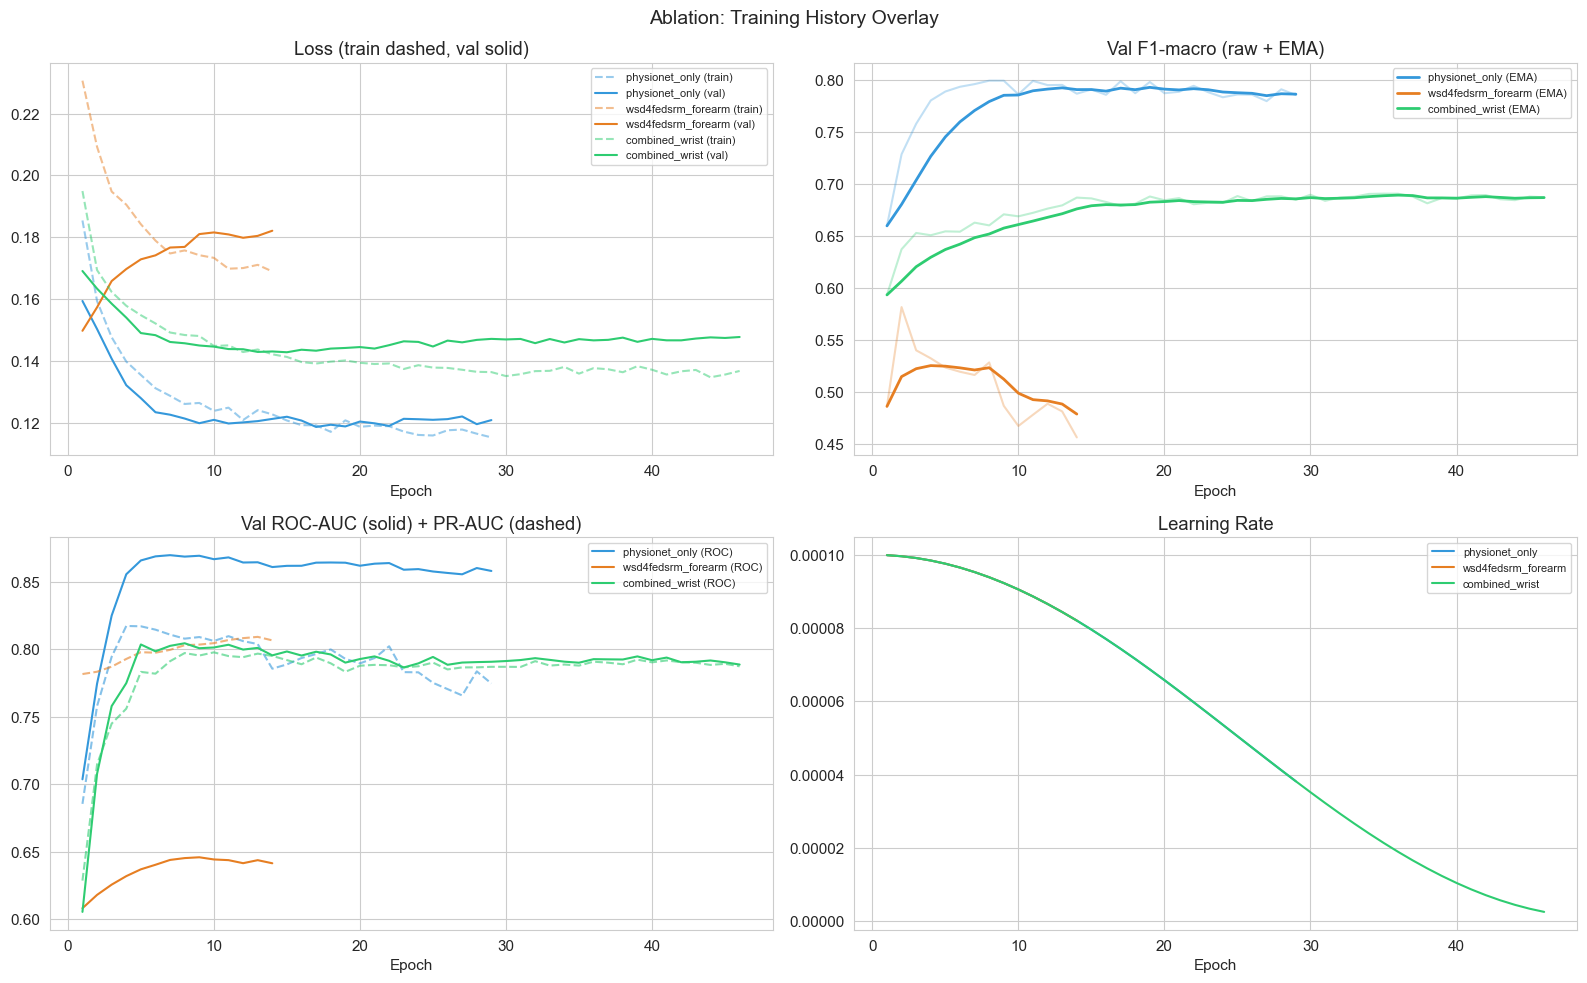

In [7]:
# ── Training history overlay ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = {'physionet_only': '#3498db', 'wsd4fedsrm_forearm': '#e67e22', 'combined_wrist': '#2ecc71'}

for name, r in all_results.items():
    h = r['history']
    ep = range(1, len(h['train_loss']) + 1)
    c = colors[name]

    axes[0, 0].plot(ep, h['train_loss'], color=c, ls='--', alpha=0.5, label=f'{name} (train)')
    axes[0, 0].plot(ep, h['val_loss'], color=c, ls='-', label=f'{name} (val)')

    axes[0, 1].plot(ep, h['val_f1_ema'], color=c, lw=2, label=f'{name} (EMA)')
    axes[0, 1].plot(ep, h['val_f1'], color=c, alpha=0.3)

    axes[1, 0].plot(ep, h['val_auc'], color=c, label=f'{name} (ROC)')
    axes[1, 0].plot(ep, h['val_pr_auc'], color=c, ls='--', alpha=0.6)

    axes[1, 1].plot(ep, h['lr'], color=c, label=name)

axes[0, 0].set_title('Loss (train dashed, val solid)')
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].set_title('Val F1-macro (raw + EMA)')
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_xlabel('Epoch')

axes[1, 0].set_title('Val ROC-AUC (solid) + PR-AUC (dashed)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].set_title('Learning Rate')
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_xlabel('Epoch')

plt.suptitle('Ablation: Training History Overlay', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history_overlay.png', dpi=150)
plt.show()

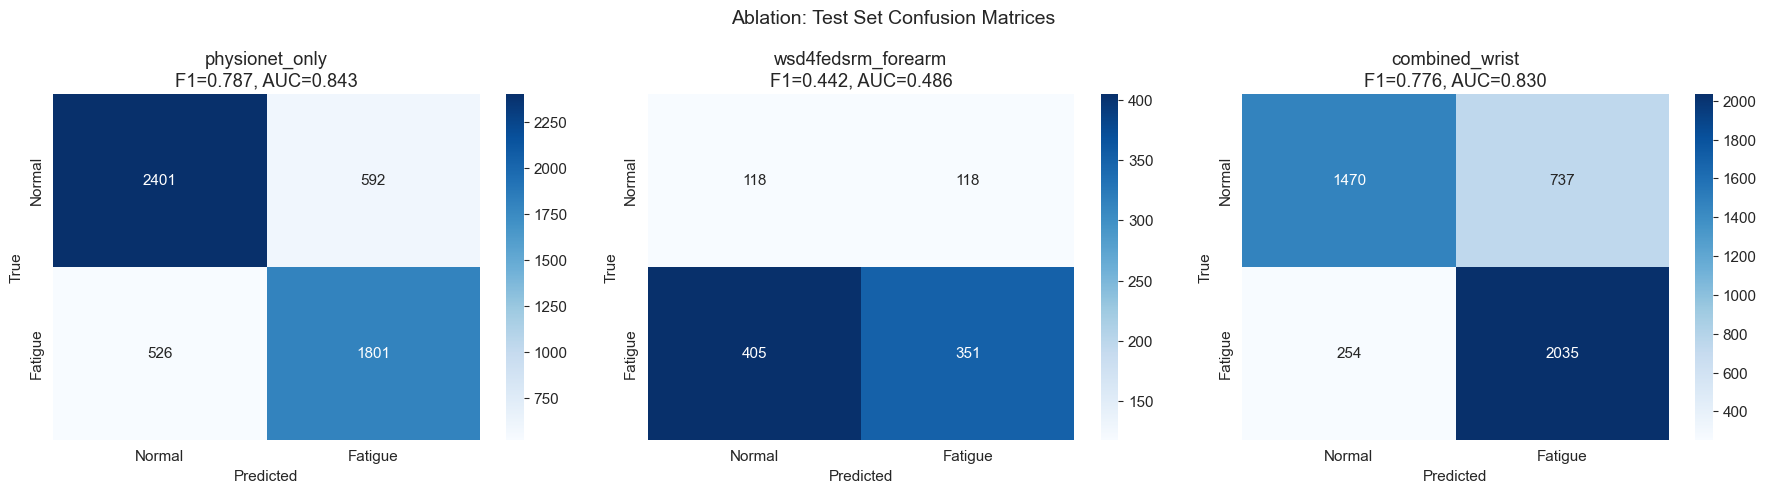

In [8]:
# ── Confusion matrices side by side ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, all_results.items()):
    cm = confusion_matrix(r['test_labels'], r['test_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fatigue'], yticklabels=['Normal', 'Fatigue'])
    ax.set_title(f'{name}\nF1={r["test_f1"]:.3f}, AUC={r["test_roc_auc"]:.3f}')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Ablation: Test Set Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=150)
plt.show()

C:\Users\paha-\AppData\Local\Temp\ipykernel_18048\2724398800.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=domains_in, patch_artist=True)
C:\Users\paha-\AppData\Local\Temp\ipykernel_18048\2724398800.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=domains_in, patch_artist=True)
C:\Users\paha-\AppData\Local\Temp\ipykernel_18048\2724398800.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=domains_in, patch_artist=True)


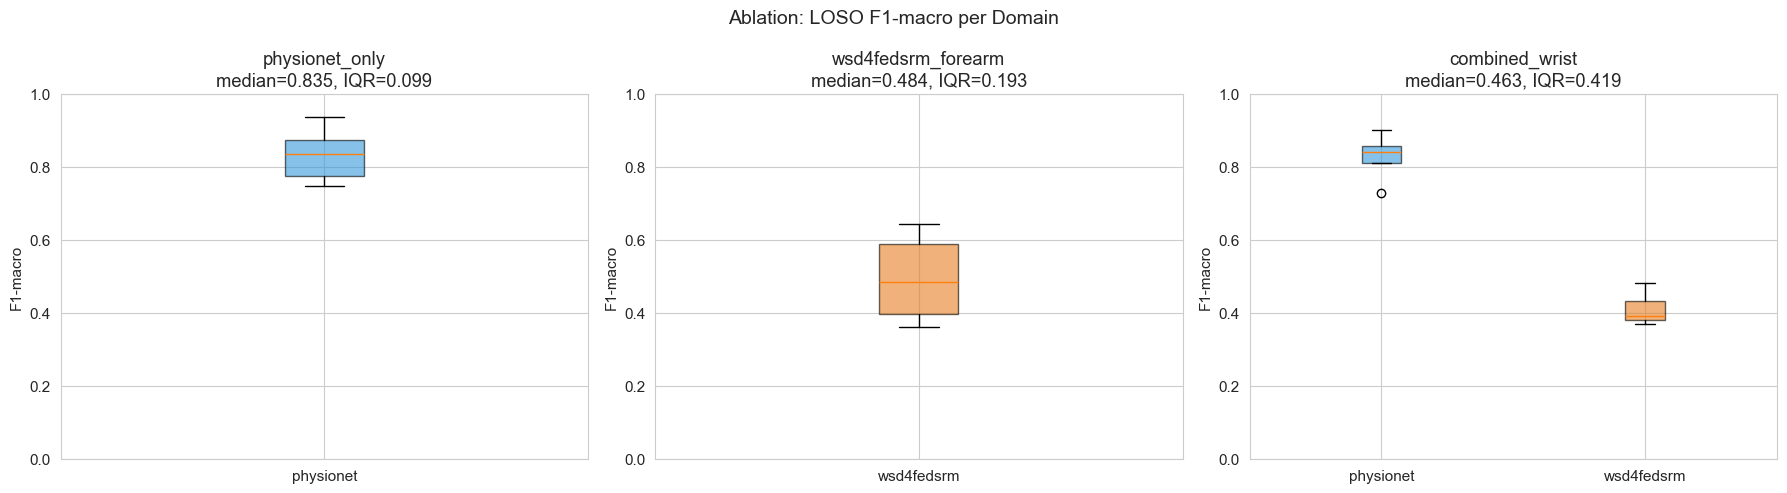

In [9]:
# ── LOSO per-domain breakdown ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_dom = {'physionet': '#3498db', 'wsd4fedsrm': '#e67e22'}

for ax, (name, r) in zip(axes, all_results.items()):
    loso = r['loso_df']
    domains_in = loso['domain'].unique()

    bp_data = [loso[loso['domain'] == d]['f1_macro'].values for d in domains_in]
    bp = ax.boxplot(bp_data, labels=domains_in, patch_artist=True)
    for patch, dom in zip(bp['boxes'], domains_in):
        patch.set_facecolor(colors_dom.get(dom, '#999999'))
        patch.set_alpha(0.6)

    ax.set_title(f'{name}\nmedian={loso["f1_macro"].median():.3f}, '
                 f'IQR={loso["f1_macro"].quantile(0.75) - loso["f1_macro"].quantile(0.25):.3f}')
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0, 1)

plt.suptitle('Ablation: LOSO F1-macro per Domain', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'loso_breakdown.png', dpi=150)
plt.show()

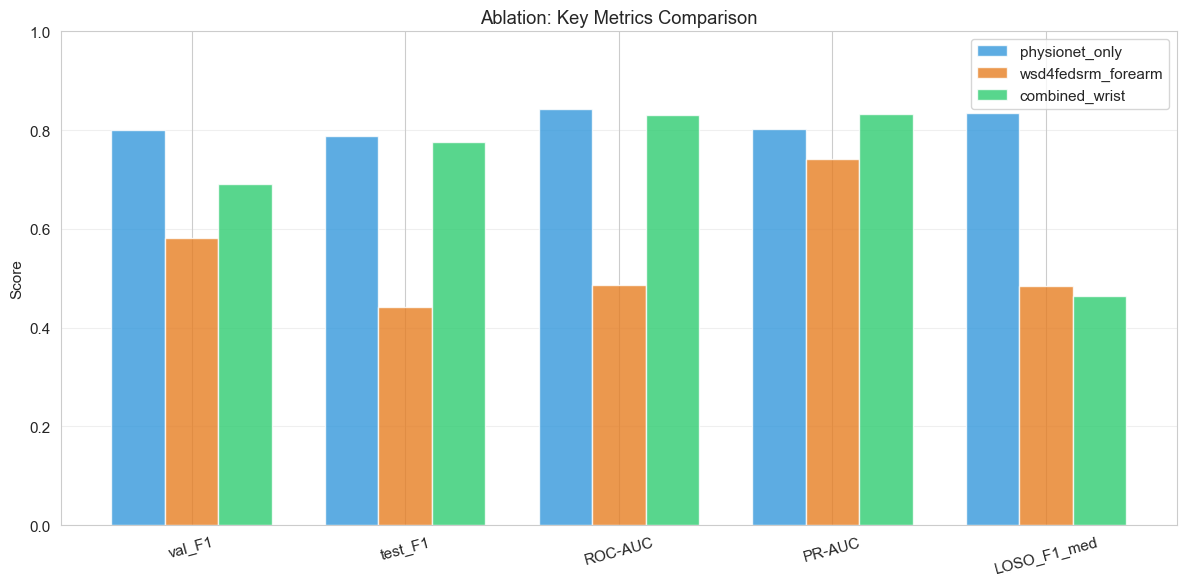

In [10]:
# ── Bar chart: key metrics comparison ──
metrics_to_plot = ['val_F1', 'test_F1', 'ROC-AUC', 'PR-AUC', 'LOSO_F1_med']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_exp = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, _) in enumerate(all_results.items()):
    vals = [comparison_df.loc[name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=name, color=colors_exp[i], alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Ablation: Key Metrics Comparison')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metrics_comparison.png', dpi=150)
plt.show()

## 7. Выводы

**Интерпретация:**
- Если `physionet_only` val_F1 ≥ 0.73 → WSD Sternum в v6.0 действительно вредил
- Если `combined_wrist` > `physionet_only` → WSD Forearm = полезное дополнение
- Если `wsd4fedsrm_forearm` < обоих → WSD сам по себе слишком мал, работает только как дополнение
- LOSO IQR для WSD-only ожидаемо высокий (~12 субъектов)

**Для диплома:** результат ablation = научный вклад о влиянии несовместимых доменов на cross-domain обучение

Completed: *Run experiments and verify* (5/5)

All experiments complete. Here's the summary:

**Ablation Results:**

| Experiment | val_F1 | test_F1 | ROC-AUC | LOSO F1 (median) | best_epoch |
|---|---|---|---|---|---|
| **physionet_only** | **0.799** | **0.787** | **0.843** | **0.835** | 8 |
| wsd4fedsrm_forearm | 0.582 | 0.442 | 0.486 | 0.484 | 2 |
| combined_wrist | 0.691 | 0.776 | 0.830 | 0.463* | 35 |

*\*combined LOSO median is dragged down by WSD folds (physionet folds within combined still score 0.840)*

**Key findings:**

1. **PhysioNet-only val_F1 = 0.799** — confirms WSD was harming performance in v6.0 (which had val_F1 ≈ 0.73 with Sternum)
2. **WSD Forearm alone barely learns** (F1 ≈ 0.44, AUC < 0.5) — too few subjects (34) with correlated sub-windows, no physio signal
3. **Combined test_F1 ≈ physionet_only** (0.776 vs 0.787) but val_F1 drops (0.69 vs 0.80) and requires 35 epochs vs 8 → WSD adds noise/slows convergence but doesn't catastrophically hurt test performance
4. **LOSO tells the real story**: physionet-only median 0.835 vs combined median 0.463 (because WSD folds are near-random). Within combined, physionet folds still get 0.840 — the model learns PhysioNet well but WSD subjects remain unpredictable

**Conclusion for diploma:** WSD4FEDSRM (even Forearm) adds no value — PhysioNet alone is sufficient and significantly cleaner.

Made changes.